In [1]:
%matplotlib inline

In [ ]:
# LABORATÓRIO 01 — ACO: OTIMIZAÇÃO POR COLÔNIA DE FORMIGAS


In [3]:
# 1. Importação das bibliotecas
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

In [4]:
# 2. Representação da rede
CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

In [5]:
# 3. Parâmetros do ACO
NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

In [6]:
# 4. Criando a matriz de feromônio
feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0

print("Matriz inicial de feromônio:")
print(feromonio)

Matriz inicial de feromônio:
[[1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]]


In [7]:
# 5. Encontrando os vizinhos de um nó
def obter_vizinhos(no):
    vizinhos = []
    for proximo in range(len(CUSTOS)):
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)
    return vizinhos

print("Vizinhos do nó 0:", obter_vizinhos(0))
print("Vizinhos do nó 2:", obter_vizinhos(2))

Vizinhos do nó 0: [1, 2]
Vizinhos do nó 2: [0, 1, 3, 4]


In [8]:
# 6. Escolhendo o próximo nó
def escolher_proximo(no_atual, visitados):
    vizinhos = obter_vizinhos(no_atual)
    candidatos = [no for no in vizinhos if no not in visitados]

    if not candidatos:
        return None

    atratividades = []
    for proximo in candidatos:
        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]
        atratividade = (fer ** ALPHA) * (1 / custo) ** BETA
        atratividades.append(atratividade)

    soma = sum(atratividades)
    probabilidades = [valor / soma for valor in atratividades]

    return random.choices(candidatos, weights=probabilidades, k=1)[0]

In [9]:
# 7. Construindo uma rota
def construir_rota():
    rota = [ORIGEM]
    atual = ORIGEM
    while atual != DESTINO:
        proximo = escolher_proximo(atual, rota)
        if proximo is None:
            return None
        rota.append(proximo)
        atual = proximo
    return rota

print("\nRotas encontradas:")
for i in range(5):
    rota = construir_rota()
    print(f"Formiga {i + 1}: {rota}")


Rotas encontradas:
Formiga 1: [0, 1, 2, 3, 4, 5]
Formiga 2: [0, 1, 2, 3, 4, 5]
Formiga 3: [0, 1, 2, 3, 4, 5]
Formiga 4: [0, 1, 2, 3, 4, 5]
Formiga 5: [0, 2, 1, 3, 4, 5]


In [10]:
# 8. Calculando o custo da rota
def calcular_custo(rota):
    total = 0
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        total += CUSTOS[origem][destino]
    return total

rota = construir_rota()
if rota is not None:
    custo = calcular_custo(rota)
    print("\nRota:", rota)
    print("Custo:", custo)


Rota: [0, 1, 2, 3, 4, 5]
Custo: 8.0


In [11]:
# 9. Depósito de feromônio
def depositar_feromonio(rota, custo):
    deposito = Q / custo
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        feromonio[origem][destino] += deposito

In [12]:
# 10. Evaporação do feromônio
def evaporar_feromonio():
    global feromonio
    feromonio *= (1 - TAXA_EVAPORACAO)
    feromonio[CUSTOS == np.inf] = 0

In [13]:
# 11. Executando o ACO
melhor_rota = None
melhor_custo = float("inf")
historico = []

for iteracao in range(NUM_ITERACOES):
    rotas = []
    for _ in range(NUM_FORMIGAS):
        rota = construir_rota()
        if rota is not None:
            custo = calcular_custo(rota)
            rotas.append((rota, custo))
            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas:
        depositar_feromonio(rota, custo)

    historico.append(melhor_custo)

print("\n========== RESULTADO ==========")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)


========== RESULTADO ==========
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


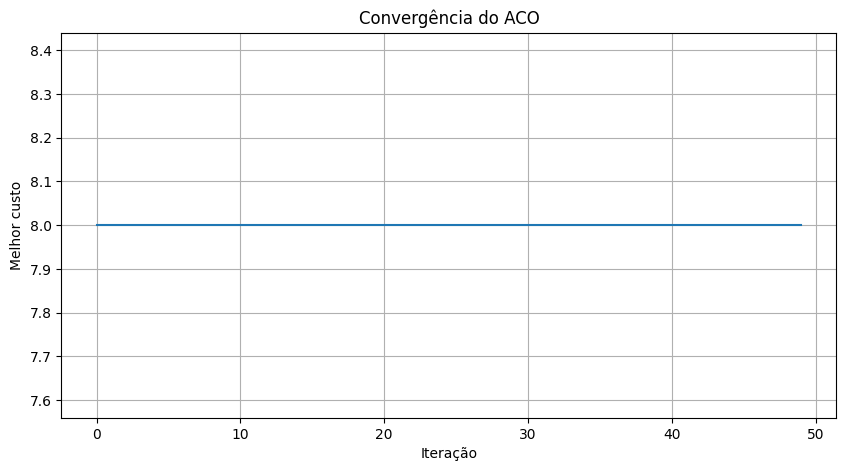

In [14]:
# 12. Visualizando a convergência
plt.figure(figsize=(10, 5))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO")
plt.grid()
plt.show()

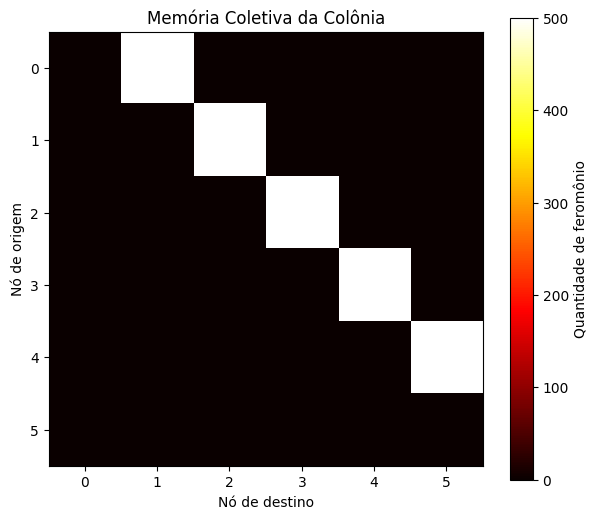


Matriz final de feromônio:
[[  0. 500.   0.   0.   0.   0.]
 [  0.   0. 500.   0.   0.   0.]
 [  0.   0.   0. 500.   0.   0.]
 [  0.   0.   0.   0. 500.   0.]
 [  0.   0.   0.   0.   0. 500.]
 [  0.   0.   0.   0.   0.   0.]]


In [15]:
# 13. Visualizando a matriz de feromônio
plt.figure(figsize=(7, 6))
plt.imshow(feromonio, cmap="hot")
plt.colorbar(label="Quantidade de feromônio")
plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")
plt.title("Memória Coletiva da Colônia")
plt.show()

print("\nMatriz final de feromônio:")
print(np.round(feromonio, 2))